In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import StandardScaler
import pickle

# leer datos

In [3]:
df_basa_full=pd.read_csv('basa_original.csv')

non_aquatic_species = 'Abies,Pinus,Juniperus,Taxus,Betula,Corylus,Alnus,Carpinus,Salix,Ulmus,Populus,Acer,Fraxinus,Fagus,Tilia,Juglans,Castanea,Quercus caducifolio,Quercus perennifolio,Pistacia,Rhamnus,Phillyrea,Buxus,Sambucus,Viburnum,Sanguisorba,Tamarix,Thymelaeaceae,Ephedra distachya,Ephedra fragilis,Ericaceae,Hereda helix,Ilex aquifolium,Viscum album,Lonicera,Vitis,Oleaceae,Myrtus,Olea,Poaceae,Lygeum spartum,Artemisia,Cichorioideae,Asteroideae,Cardueae,Rubiaceae,Centaurea,Chenopodiaceae,Caryophyllaceae,Plantago,Brassicaceae,Saxifragaceae,Fabaceae,Genista,Lotus type,Trifolium type,Rosaceae,Ribes,Boraginaceae,Sedum,Helianthemum,Lamiaceae,Urticaceae,Rumex,Berberidaceae,Euphorbiaceae,Primulaceae,Scrophulariaceae,Papaver,Campanulaceae,Convolvulaceae,Liliaceae,Iridaceae,Crassulaceae,Ranunculaceae,Cistaceae,Galium,Apiaceae,Valerianaceae,Cerealia type,Polygonaceae,Ranunculus'

species_mapping = {
        "Dec_Querc": "Quercus caducifolio",
        "Ever_Querc": "Quercus perennifolio",
        "Ephedra dist": "Ephedra distachya",
        "Ephedra frag": "Ephedra fragilis",
        "Lygeum": "Lygeum spartum",
        "Cicho": "Cichorioideae",
        "Astroi": "Asteroideae",
        "Carduaceae": "Cardueae",
        "Rubiac": "Rubiaceae",
        "Chenopo": "Chenopodiaceae",
        "Caryphy": "Caryophyllaceae",
        "Brassicac": "Brassicaceae",
        "Saxifrag": "Saxifragaceae",
        "Boraginac": "Boraginaceae",
        "Helianthem": "Helianthemum",
        "Euphorbiac": "Euphorbiaceae",
        "Primulac": "Primulaceae",
        "Scrophulari": "Scrophulariaceae",
        "Campanulac": "Campanulaceae",
        "Valerian": "Valerianaceae",
        "Cerealia": "Cerealia type",
        "Polygon": "Polygonaceae"
    }

non_aquatic_species = [s.strip() for s in non_aquatic_species.split(',')]
df_bas = df_basa_full[
    list(df_basa_full.columns[:8]) +
    [c for c in df_basa_full.columns[8:] if c in non_aquatic_species]
]

# sin variables condicionales

In [18]:
N_BOOTSTRAP=2
MIN_NO_CERO=5
ALPHA=0.05
ABUNDANCIA_MINIMA=0.1

L_MEDIA=5
MIN_VAR=1e-10

WINDOWS = {
    "9798_6253": (9798, 6253),
    "6182_3842": (6182, 3842),
    "3771_-57": (3771, -57)
}


def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_NO_CERO and serie.nunique() > 1


def bootstrap_univariante_exp(serie):
    n = len(serie)
    resultado = []

    while len(resultado) < n:
        inicio = np.random.randint(0, n)
        longitud = int(np.random.exponential(scale=L_MEDIA))
        longitud = max(1, min(longitud, n))
        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    # el tiempo no se reordena, se mantiene igual que el original
    df_boot["cal BP"] = df["cal BP"].values
    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp(df[col].values)
    return df_boot


def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2(df, sp1, sp2):
    try:
        x = df[sp1].values[::-1]
        y = df[sp2].values[::-1]

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            #print("ERROR VAR: Variance too low")
            return np.nan

        data = pd.DataFrame({sp1: x, sp2: y})
        #data_scaled = StandardScaler().fit_transform(data)

        model = VAR(data)
        results = model.fit(maxlags=1)
        A = results.coefs[0]
        #print("len:", len(x), "stdx:", np.std(x), "stdy:", np.std(y))

        return A[1][0]

    except Exception as e:
        print("ERROR VAR:", e)
        return np.nan


# cargar series temporales originales
with open("pkl/gam_original.pkl", "rb") as f:
    df_original = pickle.load(f)

especies= [col for col in df_original.columns if col != "cal BP"]
#transformar en 0 abundancias muy pequeñas
#df_original[especies] = df_original[especies].applymap(lambda x: x if x >= ABUNDANCIA_MINIMA else 0)
df_original[especies] = df_original[especies].where(
    df_original[especies] >= 0.5, 0
)

# solo utilizar especies con más de MIN_NO_CERO abundancias mayores que 0 en la serie temporal original
especies_validas = [col for col in especies if es_serie_valida(df_original[col])]
print(f"Especies válidas: {len(especies_validas)} de {len(especies)}")

# generar bootstrap
np.random.seed(42)
bootstrap_dfs = []
for i in range(N_BOOTSTRAP):
    df_boot = generar_bootstrap_df(df_original, especies_validas)
    bootstrap_dfs.append(df_boot)

# calcular cresultados por ventana

for ventana, (cal_min, cal_max) in WINDOWS.items():
    print("VENTANA:", ventana)
    ventana_original=extraer_ventana(df_original, cal_min, cal_max)
    #comprobar qué especies son válidas ya solo teniendo la ventana (no demasiados ceros)
    especies_validas_ventana= [sp for sp in especies_validas if es_serie_valida(ventana_original[sp])]
    print("especies validas en ventana:", len(especies_validas_ventana))

    n_neg = 0
    n_pos = 0
    matriz_coeficientes = np.full((len(especies_validas_ventana), len(especies_validas_ventana)), np.nan)
    matriz_sig = np.zeros((len(especies_validas_ventana), len(especies_validas_ventana)), dtype=int)

    # para cada par de especies, calcular coeficiente de sp1 a sp2 original y para cada bootstrap
    for i in range(len(especies_validas_ventana)):
        for j in range(len(especies_validas_ventana)):
            if i==j:
                continue
            sp1 = especies_validas_ventana[i]
            sp2 = especies_validas_ventana[j]

            coef_original = coef_sp1_a_sp2(ventana_original, sp1, sp2)
            matriz_coeficientes[i, j] = coef_original
            if np.isnan(coef_original):
                #print(f"Coeficiente original para {sp1} a {sp2} es NaN, se omite este par.")
                continue

            # coeficientes bootstrap
            coeficientes_bootstrap = []
            for df_boot in bootstrap_dfs:
                df_ventana = extraer_ventana(df_boot, cal_min, cal_max)
                coef_boot = coef_sp1_a_sp2(df_ventana, sp1, sp2)
                coeficientes_bootstrap.append(coef_boot)
            #eliminar NaN de coeficientes bootstrap
            coeficientes_bootstrap = [c for c in coeficientes_bootstrap if not np.isnan(c)]
            coeficientes_bootstrap = np.array(coeficientes_bootstrap)

            pc_bajo = np.percentile(coeficientes_bootstrap, 2.5)
            pc_alto = np.percentile(coeficientes_bootstrap, 97.5)
            if coef_original < pc_bajo:
                matriz_sig[i, j] = -1
                n_neg+=1
            elif coef_original > pc_alto:
                matriz_sig[i, j] = 1
                n_pos+=1

    print(f"significativos: {n_neg + n_pos}") 
    print(f"positivos: {n_pos} ({n_pos/(n_neg+n_pos)*100:.2f}%)")
    print(f"negativos: {n_neg} ({n_neg/(n_neg+n_pos)*100:.2f}%)")

    resultados_ventana = {
        "especies": especies_validas,
        "matriz_coeficientes": matriz_coeficientes,
        "matriz_significancia": matriz_sig
    }

    # guardar resultados de la ventana en un archivo pickle

    with open(f"resultados_{ventana}.pkl", "wb") as f:
        pickle.dump(resultados_ventana, f)


print("Proceso completado. ")








Especies válidas: 73 de 75
VENTANA: 9798_6253
especies validas en ventana: 61


IndexError: index -1 is out of bounds for axis 0 with size 0

DUDAS

- Las abundancias hay que escalarlas? tiene sentido usarlas así  habría que hacer el porcentaje de cada especie respecto al total? o estandarizarlas? Cuánto tiene sentido que sea la mínima abundancia posible mayor que 0?



<Axes: xlabel='cal BP'>

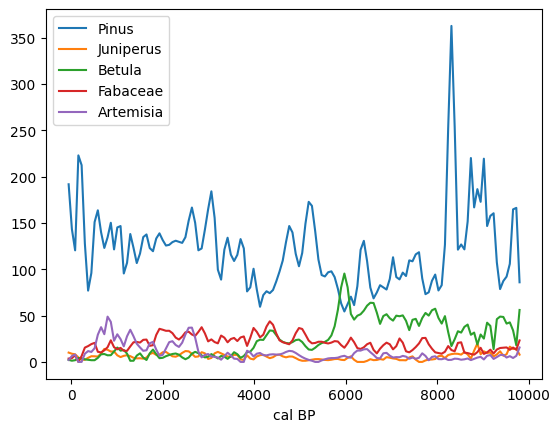

In [4]:
# plotear df_original algunas especies

df_original.plot(x="cal BP", y=["Pinus", "Juniperus", "Betula", "Fabaceae", "Artemisia"])





In [6]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 1

WINDOWS = {
    #"9798_6253": (9798, 6253),
    "6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA and serie.nunique() > 1


def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=5))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return np.nan

        data = pd.DataFrame({sp1: x, sp2: y})

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        return A[1][0]

    except:
        return np.nan


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print("Bootstrap generados.")

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # diagnóstico varianzas
    stds = df_w[especies_ventana].std()

    print("\nVarianzas mínimas:")
    print(stds.sort_values().head(10))

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p97_5 = np.percentile(coefs_boot, 97.5)

            if coef_original < p2_5:

                matriz_sig[i, j] = -1
                n_sig += 1
                n_low += 1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1
                n_sig += 1
                n_high += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")

    print(f"Pares totales evaluados: {total_pairs}")

    print(f"Coeficientes originales NaN: {nan_original} "
          f"({nan_original/total_pairs*100:.2f}%)")

    print(f"Coeficientes originales válidos: {valid_original} "
          f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        print(f"Fallos bootstrap: {bootstrap_fail} "
              f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    print(f"Cola baja: {n_low}")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    nombre_archivo = f"red_granger_{window_name}.pkl"

    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 69

Generando bootstrap...
Bootstrap generados.

VENTANA: 6182_3842
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 51

Varianzas mínimas:
Boraginaceae       0.260465
Iridaceae          0.260941
Ilex aquifolium    0.278261
Sambucus           0.301874
Rhamnus            0.343075
Buxus              0.397658
Galium             0.398901
Oleaceae           0.401214
Populus            0.530099
Salix              0.586923
dtype: float64

--- DIAGNÓSTICO ---
Pares totales evaluados: 2550
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 2550 (100.00%)
Fallos bootstrap: 12 (0.47% de válidos)

Significativos: 134 (5.25% de válidos)
Cola baja: 59
Cola alta: 75

Guardado: red_granger_6182_3842.pkl

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 1

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    #return (serie > 0).sum() >= MIN_PRESENCIA and serie.nunique() > 1
    return (serie > 0).sum() >= MIN_PRESENCIA 


def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)
        longitud=n+1
        while longitud>n:
            longitud = int(np.random.exponential(scale=n))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2, return_zero_on_fail=True):
    try:
        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return 0 if return_zero_on_fail else 0

        # Opcional: estandarizar
        # x = (x - x.mean()) / x.std()
        # y = (y - y.mean()) / y.std()

        data = pd.DataFrame({sp1: x, sp2: y})
        model = VAR(data)
        results = model.fit(maxlags=1)
        
        coef = results.coefs[0][1][0]
        
        return coef

    except:
        return (0) if return_zero_on_fail else (0)

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

#invertir el orden temporal para que vaya de más antiguo a más reciente (cal BP va de mayor a menor)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print("Bootstrap generados.")

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            p5=np.percentile(abs(coefs_boot), 95)
            #p2_5 = np.percentile(coefs_boot, 2.5)
            #p97_5 = np.percentile(coefs_boot, 97.5)

            if abs(coef_original) > p5:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

            # if coef_original < p2_5:

            #     matriz_sig[i, j] = -1
            #     n_sig += 1
            #     n_low += 1

            # elif coef_original > p97_5:

            #     matriz_sig[i, j] = 1
            #     n_sig += 1
            #     n_high += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")

    print(f"Pares totales evaluados: {total_pairs}")

    print(f"Coeficientes originales NaN: {nan_original} "
          f"({nan_original/total_pairs*100:.2f}%)")

    print(f"Coeficientes originales válidos: {valid_original} "
          f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        print(f"Fallos bootstrap: {bootstrap_fail} "
              f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    print(f"Cola baja: {n_low}")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    nombre_archivo = f"red_granger_{window_name}.pkl"

    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")


Generando bootstrap...
Bootstrap generados.

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 58

--- DIAGNÓSTICO ---
Pares totales evaluados: 3306
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 3306 (100.00%)
Fallos bootstrap: 0 (0.00% de válidos)

Significativos: 342 (10.34% de válidos)
Cola baja: 117
Cola alta: 225

Guardado: red_granger_9798_6253.pkl

Proceso terminado correctamente.


: 

In [22]:
182/377

0.4827586206896552

In [7]:
149/324

0.45987654320987653

In [8]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-4
ABUNDANCIA_MINIMA = 1

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    #return (serie > 0).sum() >= MIN_PRESENCIA and serie.nunique() > 1
    return (serie > 0).sum() >= MIN_PRESENCIA 


def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=20))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return np.nan

        data = pd.DataFrame({sp1: x, sp2: y})

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        return A[1][0]

    except:
        return np.nan


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print("Bootstrap generados.")

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # diagnóstico varianzas
    stds = df_w[especies_ventana].std()

    print("\nVarianzas mínimas:")
    print(stds.sort_values().head(10))

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p97_5 = np.percentile(coefs_boot, 97.5)

            if coef_original < p2_5:

                matriz_sig[i, j] = -1
                n_sig += 1
                n_low += 1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1
                n_sig += 1
                n_high += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")

    print(f"Pares totales evaluados: {total_pairs}")

    print(f"Coeficientes originales NaN: {nan_original} "
          f"({nan_original/total_pairs*100:.2f}%)")

    print(f"Coeficientes originales válidos: {valid_original} "
          f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        print(f"Fallos bootstrap: {bootstrap_fail} "
              f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    print(f"Cola baja: {n_low}")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    nombre_archivo = f"red_granger_{window_name}.pkl"

    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 69

Generando bootstrap...
Bootstrap generados.

VENTANA: 6182_3842
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 51

Varianzas mínimas:
Boraginaceae       0.260465
Iridaceae          0.260941
Ilex aquifolium    0.278261
Sambucus           0.301874
Rhamnus            0.343075
Buxus              0.397658
Galium             0.398901
Oleaceae           0.401214
Populus            0.530099
Salix              0.586923
dtype: float64

--- DIAGNÓSTICO ---
Pares totales evaluados: 2550
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 2550 (100.00%)
Fallos bootstrap: 18 (0.71% de válidos)

Significativos: 121 (4.75% de válidos)
Cola baja: 52
Cola alta: 69

Guardado: red_granger_6182_3842.pkl

Proceso terminado correctamente.


In [5]:
52/121


0.4297520661157025

In [7]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-4
ABUNDANCIA_MINIMA = 1

WINDOWS = {
    #"9798_6253": (9798, 6253)
    #"6182_3842": (6182, 3842)
    "3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    #return (serie > 0).sum() >= MIN_PRESENCIA and serie.nunique() > 1
    return (serie > 0).sum() >= MIN_PRESENCIA 


def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=20))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return np.nan

        data = pd.DataFrame({sp1: x, sp2: y})

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        return A[1][0]

    except:
        return np.nan


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print("Bootstrap generados.")

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # diagnóstico varianzas
    stds = df_w[especies_ventana].std()

    print("\nVarianzas mínimas:")
    print(stds.sort_values().head(10))

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p97_5 = np.percentile(coefs_boot, 97.5)

            if coef_original < p2_5:

                matriz_sig[i, j] = -1
                n_sig += 1
                n_low += 1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1
                n_sig += 1
                n_high += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")

    print(f"Pares totales evaluados: {total_pairs}")

    print(f"Coeficientes originales NaN: {nan_original} "
          f"({nan_original/total_pairs*100:.2f}%)")

    print(f"Coeficientes originales válidos: {valid_original} "
          f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        print(f"Fallos bootstrap: {bootstrap_fail} "
              f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    print(f"Cola baja: {n_low}")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    nombre_archivo = f"red_granger_{window_name}_0.1.pkl"

    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 69

Generando bootstrap...
Bootstrap generados.

VENTANA: 3771_-57
Tamaño ventana: 54 observaciones
Especies válidas en ventana: 56

Varianzas mínimas:
Sambucus           0.204266
Valerianaceae      0.218388
Ilex aquifolium    0.254882
Juglans            0.318844
Rhamnus            0.324809
Crassulaceae       0.335262
Galium             0.342884
Buxus              0.492513
Populus            0.542527
Tilia              0.546318
dtype: float64

--- DIAGNÓSTICO ---
Pares totales evaluados: 3080
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 3080 (100.00%)
Fallos bootstrap: 12 (0.39% de válidos)

Significativos: 199 (6.46% de válidos)
Cola baja: 94
Cola alta: 105

Guardado: red_granger_3771_-57_0.1.pkl

Proceso terminado correctamente.


In [11]:
94/199

0.4723618090452261

VENTANA: 9798_6253
============================================================
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 58

--- DIAGNÓSTICO ---
Pares totales evaluados: 3306
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 3306 (100.00%)
Fallos bootstrap: 382 (11.55% de válidos)

Significativos: 290 (8.77% de válidos)
Cola baja: 132
Cola alta: 158

Guardado: red_granger_9798_6253.pkl

============================================================
VENTANA: 6182_3842
============================================================
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 51

--- DIAGNÓSTICO ---
Pares totales evaluados: 2550
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 2550 (100.00%)
Fallos bootstrap: 0 (0.00% de válidos)

Significativos: 129 (5.06% de válidos)
Cola baja: 56
Cola alta: 73

Guardado: red_granger_6182_3842.pkl

Proceso terminado correctamente.


============================================================
VENTANA: 3771_-57
============================================================
Tamaño ventana: 54 observaciones
Especies válidas en ventana: 56

--- DIAGNÓSTICO ---
Pares totales evaluados: 3080
Coeficientes originales NaN: 0 (0.00%)
Coeficientes originales válidos: 3080 (100.00%)
Fallos bootstrap: 6 (0.19% de válidos)

Significativos: 219 (7.11% de válidos)
Cola baja: 108
Cola alta: 111

Guardado: red_granger_3771_-57.pkl

Proceso terminado correctamente.



In [1]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 1

BOOT_BLOCK_SCALE = 30   # tamaño medio bloque bootstrap
N_DEBUG_PAIRS = 5       # pares para imprimir percentiles

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6182, 3842),
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA


# -----------------------------------------------------
# BOOTSTRAP MULTIVARIANTE
# -----------------------------------------------------

def bootstrap_multivariante_exp(df, columnas):

    n = len(df)
    resultado = []

    while sum(len(b) for b in resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=BOOT_BLOCK_SCALE))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n

        bloque = df.iloc[indices][columnas]
        resultado.append(bloque)

    df_boot = pd.concat(resultado).iloc[:n].reset_index(drop=True)

    df_boot["cal BP"] = df["cal BP"].values

    return df_boot


def generar_bootstrap_df(df, columnas):

    return bootstrap_multivariante_exp(df, columnas)


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return np.nan

        data = pd.DataFrame({sp1: x, sp2: y})

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        return A[1][0]

    except:
        return np.nan


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

# -----------------------------------------------------
# ESCALADO GLOBAL
# -----------------------------------------------------

means = df_original[especies_cols].mean()
stds = df_original[especies_cols].std()

df_original[especies_cols] = (df_original[especies_cols] - means) / stds

# -----------------------------------------------------

especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap multivariante...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print("Bootstrap generados.")

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    debug_count = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p50 = np.percentile(coefs_boot, 50)
            p97_5 = np.percentile(coefs_boot, 97.5)

            # --------------------------------------------
            # DEBUG percentiles
            # --------------------------------------------

            if debug_count < N_DEBUG_PAIRS:

                print("\nDEBUG PAR")
                print(sp1, "→", sp2)

                print("coef original:", coef_original)
                print("percentiles:", p2_5, p50, p97_5)
                print("std bootstrap:", np.std(coefs_boot))

                debug_count += 1

            # --------------------------------------------

            if coef_original < p2_5:

                matriz_sig[i, j] = -1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    nombre_archivo = f"red_granger_{window_name}_0.1.pkl"

    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 69

Generando bootstrap multivariante...
Bootstrap generados.

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 57

DEBUG PAR
Pinus → Juniperus
coef original: 0.13938602391797597
percentiles: -0.17577078354524794 0.08160170159710273 0.29987577724418474
std bootstrap: 0.11993391385847386

DEBUG PAR
Pinus → Betula
coef original: -0.17302456799496585
percentiles: -0.20590822138707465 0.004027997825631235 0.19150809142478775
std bootstrap: 0.09376508480298121

DEBUG PAR
Pinus → Corylus
coef original: -0.10047549559852181
percentiles: -0.16401380958921036 0.005932273048136594 0.21185177744083214
std bootstrap: 0.09698145678814339

DEBUG PAR
Pinus → Alnus
coef original: -0.013369781623261412
percentiles: -0.20468445793778384 -0.009826827681838957 0.44803701496320125
std bootstrap: 0.17421057744599786

DEBUG PAR
Pinus → Salix
coef original: -0.1639047981897304
percentiles: -0.4265498287369102 -0.11186659354629301 0.1072982611

In [4]:
coefs=resultado["matriz_coeficientes"]
sig=resultado["matriz_significancia"]
print((sig != 0).sum(), "conexiones significativas")
print("Conexiones positivas:", (sig == 1).sum())
print("Conexiones negativas:", (sig == -1).sum())
print("Conexiones totales evaluadas:", np.sum(~np.isnan(coefs)))



88 conexiones significativas
Conexiones positivas: 53
Conexiones negativas: 35
Conexiones totales evaluadas: 3192


In [13]:
88/3192*100
#35/88

2.756892230576441

In [18]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# =====================================================
# CONFIG
# =====================================================

ARCHIVO_RED = "resultados_6182_3842.pkl"
ARCHIVO_SERIES = "series_equidistantes_gam.pkl"

THRESHOLD = 1000
MAX_PARES = 5
N_BOOTSTRAP = 300

# =====================================================
# FUNCIONES
# =====================================================

def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=n))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def coef_var(df, sp1, sp2):

    data = df[[sp1, sp2]]

    model = VAR(data)
    results = model.fit(maxlags=1)

    A = results.coefs[0]

    return A[1][0]


def diagnostico_par(df, sp1, sp2):

    x = df[sp1].values
    y = df[sp2].values

    std_x = np.std(x)
    std_y = np.std(y)

    corr_lag = np.corrcoef(x[1:], y[:-1])[0,1]

    data = pd.DataFrame({sp1: x, sp2: y})

    try:
        cond = np.linalg.cond(data)
    except:
        cond = np.nan

    return std_x, std_y, corr_lag, cond


# =====================================================
# CARGAR DATOS
# =====================================================

with open(ARCHIVO_RED, "rb") as f:
    red = pickle.load(f)

with open(ARCHIVO_SERIES, "rb") as f:
    df = pickle.load(f)

matriz = red["matriz_coeficientes"]
especies = red["especies"]

# =====================================================
# BUSCAR PARES PROBLEMÁTICOS
# =====================================================

mask = np.abs(matriz) > THRESHOLD
indices = np.argwhere(mask)

print(f"\nTotal pares problemáticos: {len(indices)}")

# limitar
indices = indices[:MAX_PARES]

# =====================================================
# LOOP PARES
# =====================================================

for idx, (i, j) in enumerate(indices):

    sp1 = especies[i]
    sp2 = especies[j]
    coef_original = matriz[i, j]

    print("\n" + "="*60)
    print(f"PAR {idx+1}")
    print(sp1, "→", sp2)
    print("coef:", coef_original)

    # -----------------------------
    # DIAGNÓSTICO NUMÉRICO
    # -----------------------------

    std_x, std_y, corr_lag, cond = diagnostico_par(df, sp1, sp2)

    print("\nDiagnóstico:")
    print("std:", std_x, std_y)
    print("corr lag1:", corr_lag)
    print("condition number:", cond)

    if std_x < 1e-4 or std_y < 1e-4:
        print("⚠️ Posible varianza muy baja")

    if abs(corr_lag) > 0.9:
        print("⚠️ Alta colinealidad temporal")

    if cond > 1e6:
        print("⚠️ Sistema mal condicionado")

    # -----------------------------
    # PLOT SERIES
    # -----------------------------

    t = df["cal BP"]

    plt.figure(figsize=(10,4))

    plt.plot(t, df[sp1], label=sp1)
    plt.plot(t, df[sp2], label=sp2)

    plt.gca().invert_xaxis()
    plt.title(f"{sp1} → {sp2}")
    plt.legend()

    plt.show()

    # -----------------------------
    # BOOTSTRAP
    # -----------------------------

    coefs_boot = []

    for _ in range(N_BOOTSTRAP):

        s1 = bootstrap_univariante_exp(df[sp1].values)
        s2 = bootstrap_univariante_exp(df[sp2].values)

        df_b = pd.DataFrame({sp1: s1, sp2: s2})

        try:
            coef = coef_var(df_b, sp1, sp2)
            coefs_boot.append(coef)
        except:
            continue

    coefs_boot = np.array(coefs_boot)

    if len(coefs_boot) == 0:
        print("No bootstrap válido")
        continue

    # -----------------------------
    # PLOT DISTRIBUCIÓN
    # -----------------------------

    plt.figure(figsize=(8,4))

    plt.hist(coefs_boot, bins=50)
    plt.axvline(coef_original, linestyle="--")

    plt.title("Bootstrap coeficientes")
    plt.xlabel("coef VAR")

    plt.show()

    # -----------------------------
    # ESTADÍSTICAS
    # -----------------------------

    print("\nBootstrap stats:")
    print("mean:", np.mean(coefs_boot))
    print("std:", np.std(coefs_boot))
    print("p2.5:", np.percentile(coefs_boot, 2.5))
    print("p97.5:", np.percentile(coefs_boot, 97.5))


Total pares problemáticos: 0
